In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_dscto_base = "datos/Descuentos históricos/dscto_base.xlsx"
dsctos_base = pd.read_excel(path_dscto_base, header=0)
dsctos_base.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDBA,,ANSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
1,NaN,V,ZDBA,,ARSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
2,NaN,V,ZDBA,,CHSJ,,,915,VIENESA SUREÑA 12x250 GR SJ,29.02.2024,...,CB,32,,-10.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
3,NaN,V,ZDBA,,CHSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
4,NaN,V,ZDBA,,CLSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material


In [3]:
print(dsctos_base.columns)
print(dsctos_base.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                       '],
      dtype='str')
(3644, 23)


In [4]:
cols_dscto_base = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_base = dsctos_base[cols_dscto_base]
dsctos_base.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
1,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
2,915,CB,32,ZDBA,05.02.2024,29.02.2024,-10.0
3,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
4,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0


In [5]:
path_dscto_volumen = "datos/Descuentos históricos/dscto_volumen.xlsx"
dsctos_volumen = pd.read_excel(path_dscto_volumen, header=0)
dsctos_volumen.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDVL,,SGSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,"15,00-",%,0,,2,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
1,NaN,V,ZDVL,,SGSJ,,,3456,"SALAME LAMINADO 1,6 KG LP",29.02.2024,...,CB,32,,"10,00-",%,0,,4,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
2,NaN,V,ZDVL,,SGSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,54,,"15,00-",%,0,,2,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
3,NaN,V,ZDVL,,SGSJ,,,3456,"SALAME LAMINADO 1,6 KG LP",29.02.2024,...,CB,54,,"10,00-",%,0,,4,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
4,NaN,V,ZDVL,,ANSJ,,,6770,QUESO GAUDA LAMINADO 1KG.LOS NOGALES,25.04.2024,...,MY,57,,"21,20-",%,0,,54,A978,C.Comerc./G.Cadenas/Org.Ventas/Material


In [6]:
print(dsctos_volumen.columns)
print(dsctos_volumen.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                      '],
      dtype='str')
(2181, 23)


In [7]:
cols_dscto_volumen = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_volumen = dsctos_volumen[cols_dscto_volumen]
dsctos_volumen.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDVL,27.05.2024,08.06.2024,"15,00-"
1,3456,CB,32,ZDVL,07.02.2024,29.02.2024,"10,00-"
2,3071,CB,54,ZDVL,27.05.2024,08.06.2024,"15,00-"
3,3456,CB,54,ZDVL,07.02.2024,29.02.2024,"10,00-"
4,6770,MY,57,ZDVL,16.04.2024,25.04.2024,"21,20-"


In [8]:
path_dscto_binario = "datos/Descuentos históricos/dscto_binario.xlsx"
dsctos_binario = pd.read_excel(path_dscto_binario, header=0)
dsctos_binario.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDVE,,SGSJ,,,3982,PEPPERONI HORECA LP BOLSA 4 X 500G.,01.12.2025,...,CB,32,,"5,00-",%,0,,,A979,C.Comerc./G.Cadenas/Tipo.N/Org.Ventas/Material
1,NaN,V,ZDVE,,SGSJ,,,3982,PEPPERONI HORECA LP BOLSA 4 X 500G.,01.12.2025,...,CB,54,,"5,00-",%,0,,,A979,C.Comerc./G.Cadenas/Tipo.N/Org.Ventas/Material
2,NaN,V,ZDVE,,,,,20,ARROLLADO LOMO CON AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material
3,NaN,V,ZDVE,,,,,27,ARROLLADO LOMO SIN AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material
4,NaN,V,ZDVE,,,,,30,ARROLLADO HUASO CON AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material


In [9]:
print(dsctos_binario.columns)
print(dsctos_binario.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                             '],
      dtype='str')
(1310, 23)


In [10]:
cols_dscto_binario = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",   
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_binario = dsctos_binario[cols_dscto_binario]
dsctos_binario.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3982,CB,32,ZDVE,01.12.2025,01.12.2025,"5,00-"
1,3982,CB,54,ZDVE,01.12.2025,01.12.2025,"5,00-"
2,20,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"
3,27,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"
4,30,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"


In [11]:
# Juntamos los dsctos en una sola base para facilitar su uso posterior:
dsctos = pd.concat([dsctos_base, dsctos_volumen, dsctos_binario], ignore_index=True)
dsctos.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
1,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
2,915,CB,32,ZDBA,05.02.2024,29.02.2024,-10.0
3,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
4,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0


In [12]:
fechas_cambios_dsctos = dsctos.groupby(["Válido de "]).agg(
    n_cambios=pd.NamedAgg(column="Material", aggfunc="count")
).reset_index().sort_values("n_cambios", ascending=False)

fechas_cambios_dsctos.columns = ["fecha", "n_cambios_dsctos"]

fechas_cambios_dsctos.head()

,fecha,n_cambios_dsctos
35,02.03.2026,824
147,18.07.2022,645
237,30.03.2026,342
251,31.03.2026,218
91,10.06.2024,215


In [13]:
path_p_lista = "datos/Historial Precios Lista.xlsx"
precios_lista = pd.read_excel(path_p_lista, header=0)
precios_lista.head()

,Aplicación,Tipo de condición,Clase doc.ventas,Organización ventas,Canal distribución,Grupo precio cliente,Material,Descripción material,Fin de validez,Válido de,...,Canal Comercial,Grandes Cadenas,Status tratamiento,Importe,Moneda condición,UM de precio,Unidad de medida,Cantidad escala,Nombre de tabla,Descripción breve
0,V,ZP00,ZAIA,AGRO,NaN,NaN,9979802,ALMENDRA NON PAREIL,9999-12-31,2023-04-19,...,EX,NaN,NaN,7952300,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
1,V,ZP00,ZAIA,AGRO,NaN,NaN,9979805,ALMENDRA CARMEL,9999-12-31,2023-04-19,...,EX,NaN,NaN,7952300,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
2,V,ZP00,ZAIA,AGRO,NaN,NaN,9802,NARANJAS LANE LATE,9999-12-31,2025-08-27,...,OT,NaN,NaN,289200,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
3,V,ZP00,ZAIA,AGRO,AG,NaN,9800,NARANJAS FUKUMOTO,9999-12-31,2025-08-27,...,NaN,NaN,NaN,1917800,CLP,10000,KG,0,A973,ClDocVenta/Org.Ventas/Can.distr./Material
4,V,ZP00,ZAIA,AGRO,AG,NaN,9801,NARANJAS WASHINTONG PARENT,2025-08-07,2025-08-01,...,NaN,NaN,NaN,495431,CLP,10000,KG,0,A973,ClDocVenta/Org.Ventas/Can.distr./Material


In [14]:
fechas_cambios_precios = precios_lista.groupby(["Válido de"]).agg(
    n_cambios=pd.NamedAgg(column="Material", aggfunc="count")
).reset_index().sort_values("n_cambios", ascending=False)

fechas_cambios_precios.columns = ["fecha", "n_cambios_precios"]

fechas_cambios_precios.head()

,fecha,n_cambios_precios
305,2025-01-02,1280
19,2019-07-03,897
331,2025-04-14,867
255,2024-07-15,800
187,2023-10-13,740


In [17]:
tabla_cambios_por_fecha = (
    fechas_cambios_precios.assign(
        fecha=lambda df: pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
    )
    .merge(
        fechas_cambios_dsctos.assign(
            fecha=lambda df: pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
        ),
        on="fecha",
        how="outer"
    )
    .fillna({"n_cambios_precios": 0, "n_cambios_dsctos": 0})
    .assign(
        n_cambios_precios=lambda df: df["n_cambios_precios"].astype(int),
        n_cambios_dsctos=lambda df: df["n_cambios_dsctos"].astype(int),
        n_cambios_total=lambda df: df["n_cambios_precios"] + df["n_cambios_dsctos"]
    )
    .sort_values("fecha")
    .reset_index(drop=True)
)

tabla_cambios_por_fecha = tabla_cambios_por_fecha[
    tabla_cambios_por_fecha["fecha"].dt.year.isin([2025, 2026])
]

tabla_cambios_por_fecha.sort_values("n_cambios_total", ascending=False).head(n=20)

,fecha,n_cambios_precios,n_cambios_dsctos,n_cambios_total
385,2025-01-02,1280,12,1292
415,2025-04-14,867,5,872
534,2026-03-02,21,824,845
549,2026-03-30,364,342,706
436,2025-06-02,621,34,655
484,2025-10-01,482,26,508
397,2025-02-12,489,0,489
435,2025-06-01,429,15,444
399,2025-02-24,405,0,405
551,2026-04-01,251,43,294


Text(0, 0.5, 'N cambios total')

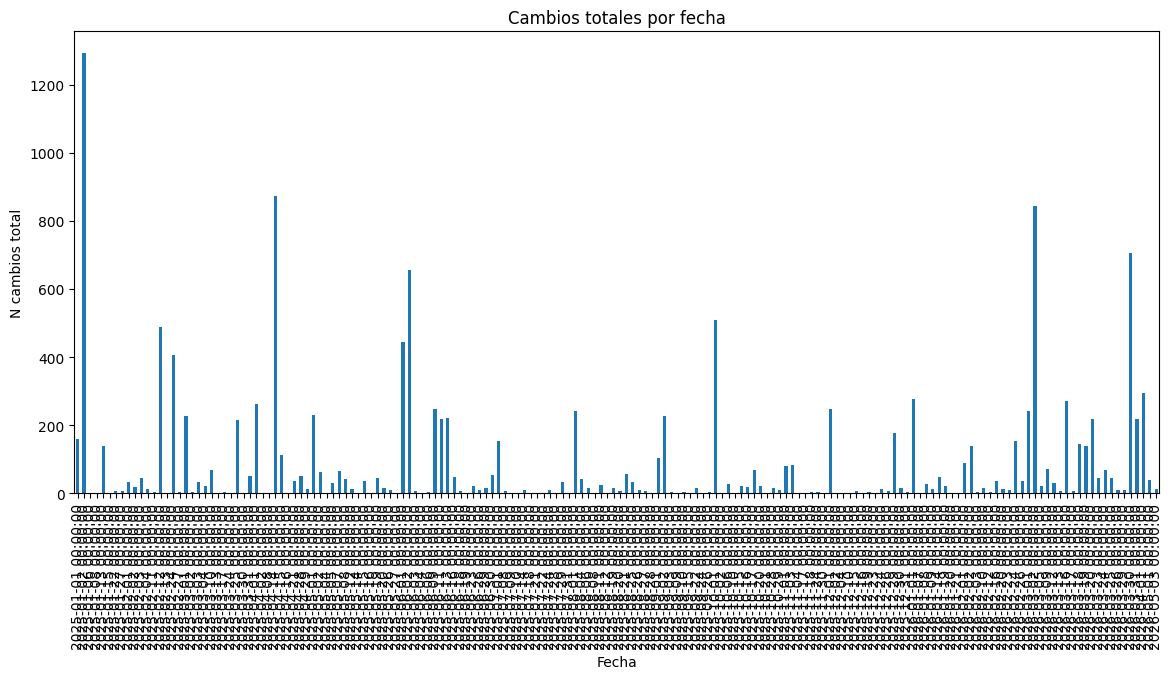

In [16]:
ax = tabla_cambios_por_fecha.plot(
    x="fecha",
    y="n_cambios_total",
    kind="bar",
    figsize=(14, 6),
    legend=False,
    title="Cambios totales por fecha"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("N cambios total")
